## Connect to cloud storage

In [1]:
ENDPOINT           = 'https://nyu1.osn.mghpcc.org'
EAEEE4000_PROFILE  = 'eaeee4000'
LEAPBUCKET         = 'leap-edu-test'
NYC4URBAN_ZARR_DIR = 'nyc4urban/nyc4urban.zarr'
import fsspec
import fsspec, os
fs = fsspec.filesystem(
    's3',
    anon          = False,
    profile       = EAEEE4000_PROFILE,
    client_kwargs = {'endpoint_url': ENDPOINT}
)
fs_mapper = fs.get_mapper(
    os.path.join(LEAPBUCKET, NYC4URBAN_ZARR_DIR)
)
fs.ls('leap-edu-test')

['leap-edu-test/nyc4urban']

In [2]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
# Confirm that the GPU is detected
assert torch.cuda.is_available()
# Get the GPU device name.
device_name = torch.cuda.get_device_name()
n_gpu = torch.cuda.device_count()
print(f"Found device: {device_name}, n_gpu: {n_gpu}")
device = torch.device("cuda")

Found device: Tesla T4, n_gpu: 1


In [4]:
import numpy as np
import xarray
xar = xarray.open_dataset(fs_mapper, engine='zarr', chunks={}).to_array()
xar
# remove auxiliary dataset dimension
xar = xar[0,...]
xar.shape

(30537, 29, 288, 288)

## Roof solar panel identification

In [5]:
import numpy as np
import xarray as xr
from scipy import ndimage
from skimage import measure, morphology
import matplotlib.pyplot as plt

class SolarRoofAnalyzer:
    """
    Solar Roof Potential Analyzer
    Evaluates the feasibility and number of solar panels to be installed based on roof area and characteristics.
    """
    def __init__(self, xar_data):
        self.xar_data = xar_data
        
        # Spatial parameters - Each pixel represents 0.5m x 0.5m of actual area
        self.PIXEL_AREA = 0.25  # Square meters per pixel
        
        # Solar panel parameters - Based on a standard 400W monocrystalline panel
        self.PANEL_WIDTH = 1.70   # Width (meters)
        self.PANEL_HEIGHT = 1.00  # Height (meters)
        self.PANEL_POWER = 400    # Power (W)
        self.PANEL_SPACING = 0.05 # Spacing between panels (meters)
        
        # Performance evaluation parameters
        self.PERFORMANCE_RATIO = 0.75  # System performance ratio
        self.DAILY_SUNHOURS = 5.0     # Average daily sunlight hours
        self.FLAT_ROOF_THRESHOLD = 5   # Threshold (degrees) for determining flat roofs
        self.SUITABILITY_THRESHOLD = 0.7  # Suitability threshold for solar installation

    def analyze_location(self, location_idx):
        """Analyze the solar installation potential for a specified location."""
        data = self.xar_data[location_idx].values
        building_mask = (data[28] == 5)
        
        labeled_roofs, num_roofs = self._identify_roofs(building_mask)
        if num_roofs == 0:
            print(f"No buildings detected at location {location_idx}.")
            return None
            
        results = []
        for roof_id in range(1, num_roofs + 1):
            roof_result = self._analyze_roof(
                roof_id, labeled_roofs, 
                data[15],  # Elevation data
                data[25]   # Thermal infrared data
            )
            results.append(roof_result)
        
        # Generate visual results
        self._visualize_analysis(data, labeled_roofs, results)
            
        return self._summarize_results(results, labeled_roofs)

    def _identify_roofs(self, building_mask):
        """
        Identify individual roof areas.
        
        Steps:
        1. Apply morphological opening to remove noise - cleans small, isolated pixels.
        2. Apply morphological closing to fill gaps within roof areas.
        3. Label connected regions to identify individual roofs.
        
        Parameters:
            building_mask: Binary mask indicating building areas.
            
        Returns:
            Labeled roofs and number of identified roofs.
        """
        kernel = np.ones((3, 3), np.uint8)
        mask = morphology.opening(building_mask.astype(np.uint8), kernel)
        mask = morphology.closing(mask, kernel)
        return ndimage.label(mask)

    def _analyze_roof(self, roof_id, labeled_roofs, elevation, thermal):
        """
        Analyze the characteristics and solar potential of a single roof.
        
        Determines the number of solar panels required based on roof size
        and evaluates the suitability for installation.
        
        Parameters:
            roof_id: Unique identifier for the roof.
            labeled_roofs: Array with labeled roof regions.
            elevation: Elevation data array.
            thermal: Thermal infrared data array.
        
        Returns:
            Dictionary with complete analysis results for the roof.
        """
        # Get the roof region and calculate the area (square meters)
        roof_mask = (labeled_roofs == roof_id)
        area = np.sum(roof_mask) * self.PIXEL_AREA
        
        # Convert area from square meters to square feet
        area_sqft = area * 10.764
        
        # Determine house type and target number of solar panels based on area
        if area_sqft <= 1000:  # Small house
            target_panels = np.random.randint(15, 21)  # 15-20 panels
            monthly_energy = np.random.randint(600, 801)  # 600-800 kWh
        elif area_sqft <= 1500:  # Medium house
            target_panels = np.random.randint(20, 31)  # 20-30 panels
            monthly_energy = np.random.randint(800, 1201)  # 800-1200 kWh
        else:  # Large house
            target_panels = np.random.randint(30, 41)  # 30-40 panels
            monthly_energy = np.random.randint(1200, 2001)  # 1200-2000 kWh
        
        # Analyze roof physical characteristics
        dy, dx = np.gradient(elevation)
        slope = np.degrees(np.arctan(np.sqrt(dx[roof_mask]**2 + dy[roof_mask]**2)))
        aspect = np.degrees(np.arctan2(dy[roof_mask], dx[roof_mask])) % 360
        
        # Evaluate suitability
        is_flat = np.std(slope) < self.FLAT_ROOF_THRESHOLD
        suitability = self._calculate_suitability(
            np.mean(slope), 
            np.mean(aspect),
            np.mean(thermal[roof_mask]) / np.max(thermal),
            is_flat
        )
        
        # Determine if the roof is suitable for installation
        is_suitable = suitability >= self.SUITABILITY_THRESHOLD
        
        # Calculate usable area and number of solar panels that can be installed
        suitable_area = area * (0.9 if is_flat else 0.7)
        panel_area = (self.PANEL_WIDTH + self.PANEL_SPACING) * (self.PANEL_HEIGHT + self.PANEL_SPACING)
        max_panels = int(suitable_area / panel_area)
        
        # If unsuitable, set the number of panels to 0
        num_panels = min(max_panels, target_panels) if is_suitable else 0
        
        # Calculate energy production
        daily_energy = num_panels * self.PANEL_POWER * self.DAILY_SUNHOURS * suitability * self.PERFORMANCE_RATIO / 1000
        
        return {
            'roof_id': roof_id,
            'area': area,
            'area_sqft': area_sqft,
            'house_type': 'Small house' if area_sqft <= 1000 else 'Medium house' if area_sqft <= 1500 else 'Large house',
            'target_panels': target_panels,
            'actual_panels': num_panels,
            'monthly_energy_target': monthly_energy,
            'daily_energy': daily_energy,
            'annual_energy': daily_energy * 365,
            'is_flat': is_flat,
            'suitability': suitability,
            'is_suitable': is_suitable,
            'slope': np.mean(slope),
            'aspect': np.mean(aspect)
        }

    def _calculate_suitability(self, slope, aspect, thermal_score, is_flat):
        """
        Evaluate the solar suitability of the roof.
        
        Parameters:
            slope: Average slope of the roof.
            aspect: Average aspect (direction) of the roof.
            thermal_score: Normalized thermal infrared data score.
            is_flat: Whether the roof is flat.
        
        Returns:
            Suitability score for solar installation.
        """
        if is_flat:
            return 0.9  # Flat roofs can be adjusted to the optimal angle
        
        slope_score = 1.0 if 20 <= slope <= 40 else 0.7 if 10 <= slope <= 50 else 0.3
        aspect_score = np.cos(np.radians(aspect - 180)) * 0.5 + 0.5
        
        return slope_score * 0.4 + aspect_score * 0.4 + thermal_score * 0.2

    def _visualize_analysis(self, data, labeled_roofs, results):
        """
        Generate visualization of the analysis results.
        Annotate the image with building IDs and suitability evaluation results.
        
        Parameters:
            data: Input data array for the location.
            labeled_roofs: Labeled roof regions.
            results: List of analysis results for each roof.
        """
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # 1. RGB true-color image
        rgb_data = np.stack([data[1], data[3], data[5]], axis=-1)
        rgb_normalized = (rgb_data - rgb_data.min()) / (rgb_data.max() - rgb_data.min())
        axes[0, 0].imshow(rgb_normalized)
        axes[0, 0].set_title('RGB True-Color Image')
        
        # Add annotations with building IDs on the RGB image
        for result in results:
            roof_id = result['roof_id']
            roof_mask = (labeled_roofs == roof_id)
            y_indices, x_indices = np.where(roof_mask)
            center_y, center_x = int(np.mean(y_indices)), int(np.mean(x_indices))
            
            # Add building information annotations (including suitability evaluation)
            label_text = f"ID: {roof_id}\n{result['house_type']}\n{'Suitable' if result['is_suitable'] else 'Not Suitable'}\n{result['actual_panels']} panels"
            axes[0, 0].text(center_x, center_y, label_text,
                            color='red' if result['is_suitable'] else 'blue',
                            fontsize=7, fontweight='bold',
                            ha='center', va='center',
                            bbox=dict(facecolor='white', alpha=0.7, pad=2))
        
        # 2. Elevation data
        elevation_vis = axes[0, 1].imshow(data[15], cmap='terrain')
        plt.colorbar(elevation_vis, ax=axes[0, 1])
        axes[0, 1].set_title('Elevation Data (meters)')
        
        # 3. Roof identification results
        roof_vis = axes[0, 2].imshow(labeled_roofs, cmap='tab20')
        plt.colorbar(roof_vis, ax=axes[0, 2])
        axes[0, 2].set_title('Roof Identification Results')
        
        # Add annotations with IDs on the roof identification image
        for result in results:
            roof_id = result['roof_id']
            roof_mask = (labeled_roofs == roof_id)
            y_indices, x_indices = np.where(roof_mask)
            center_y, center_x = int(np.mean(y_indices)), int(np.mean(x_indices))
            axes[0, 2].text(center_x, center_y, str(roof_id),
                            color='black', fontsize=12, fontweight='bold',
                            ha='center', va='center',
                            bbox=dict(facecolor='white', alpha=0.7, pad=2))
        
        # 4. Slope analysis
        dy, dx = np.gradient(data[15])
        slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
        slope_vis = axes[1, 0].imshow(slope, cmap='YlOrRd')
        plt.colorbar(slope_vis, ax=axes[1, 0])
        axes[1, 0].set_title('Roof Slope (degrees)')
        
        # 5. Thermal infrared data
        thermal_vis = axes[1, 1].imshow(data[25], cmap='hot')
        plt.colorbar(thermal_vis, ax=axes[1, 1])
        axes[1, 1].set_title('Thermal Infrared Data')
        
        # 6. Suitability score visualization
        suitability_map = np.zeros_like(labeled_roofs, dtype=float)
        for result in results:
            roof_id = result['roof_id']
            roof_mask = (labeled_roofs == roof_id)
            suitability_map[roof_mask] = result['suitability']
            
            y_indices, x_indices = np.where(roof_mask)
            center_y, center_x = int(np.mean(y_indices)), int(np.mean(x_indices))
            
            # Add suitability annotations
            label_text = f"{roof_id}\n{result['suitability']:.2f}\n{'Suitable' if result['is_suitable'] else 'Not Suitable'}"
            axes[1, 2].text(center_x, center_y, label_text,
                            color='black', fontsize=7, fontweight='bold',
                            ha='center', va='center',
                            bbox=dict(facecolor='white', alpha=0.7, pad=2))
        
        suit_vis = axes[1, 2].imshow(suitability_map, cmap='RdYlGn', vmin=0, vmax=1)
        plt.colorbar(suit_vis, ax=axes[1, 2])
        axes[1, 2].set_title('Suitability Scores for Installation')
        
        plt.tight_layout()
        plt.show()

    def _summarize_results(self, results, labeled_roofs):
        """
        Generate a summary report of the analysis, including suitability assessment results.
        
        Parameters:
            results: List of analysis results for each roof.
            labeled_roofs: Array of labeled roofs.
        
        Returns:
            Dictionary containing summarized results for all analyzed roofs.
        """
        total_energy = sum(r['annual_energy'] for r in results)
        total_panels = sum(r['actual_panels'] for r in results)
        suitable_roofs = sum(1 for r in results if r['is_suitable'])
        
        print("\n=== Solar Installation Potential Analysis Report ===")
        print(f"Number of identified roofs: {len(results)}")
        print(f"Number of suitable roofs: {suitable_roofs}")
        print(f"Total number of solar panels that can be installed: {total_panels}")
        print(f"Estimated annual energy production: {total_energy:.1f} kWh")
        print(f"Estimated annual economic benefit: {total_energy * 0.5:.1f} USD")
        
        for r in results:
            print(f"\nRoof {r['roof_id']}:")
            print(f"  Area: {r['area']:.1f} square meters ({r['area_sqft']:.1f} square feet)")
            print(f"  House type: {r['house_type']}")
            print(f"  Suitability score: {r['suitability']:.2f}")
            print(f"  Installation suitability assessment: {'Suitable' if r['is_suitable'] else 'Not Suitable'}")
            if r['is_suitable']:
                print(f"  Recommended number of panels: {r['target_panels']}")
                print(f"  Actual number of panels that can be installed: {r['actual_panels']}")
                print(f"  Target monthly energy usage: {r['monthly_energy_target']} kWh")
                print(f"  Estimated annual energy production: {r['annual_energy']:.1f} kWh")
            print(f"  Is flat roof: {'Yes' if r['is_flat'] else 'No'}")
        
        return {
            'roof_results': results,
            'total_panels': total_panels,
            'total_energy': total_energy,
            'suitable_roofs': suitable_roofs,
            'labeled_roofs': labeled_roofs
        }

In [6]:
def analyze_solar_potential(xar_data, location_idx=100):
    """
    Main function: Analyze the solar installation potential for a specified location.
    
    Parameters:
        xar_data: xarray dataset containing input data for analysis.
        location_idx: Index of the location to analyze.
    
    Returns:
        Dictionary containing summarized results and visualizations of the analysis.
    """
    analyzer = SolarRoofAnalyzer(xar_data)
    return analyzer.analyze_location(location_idx)

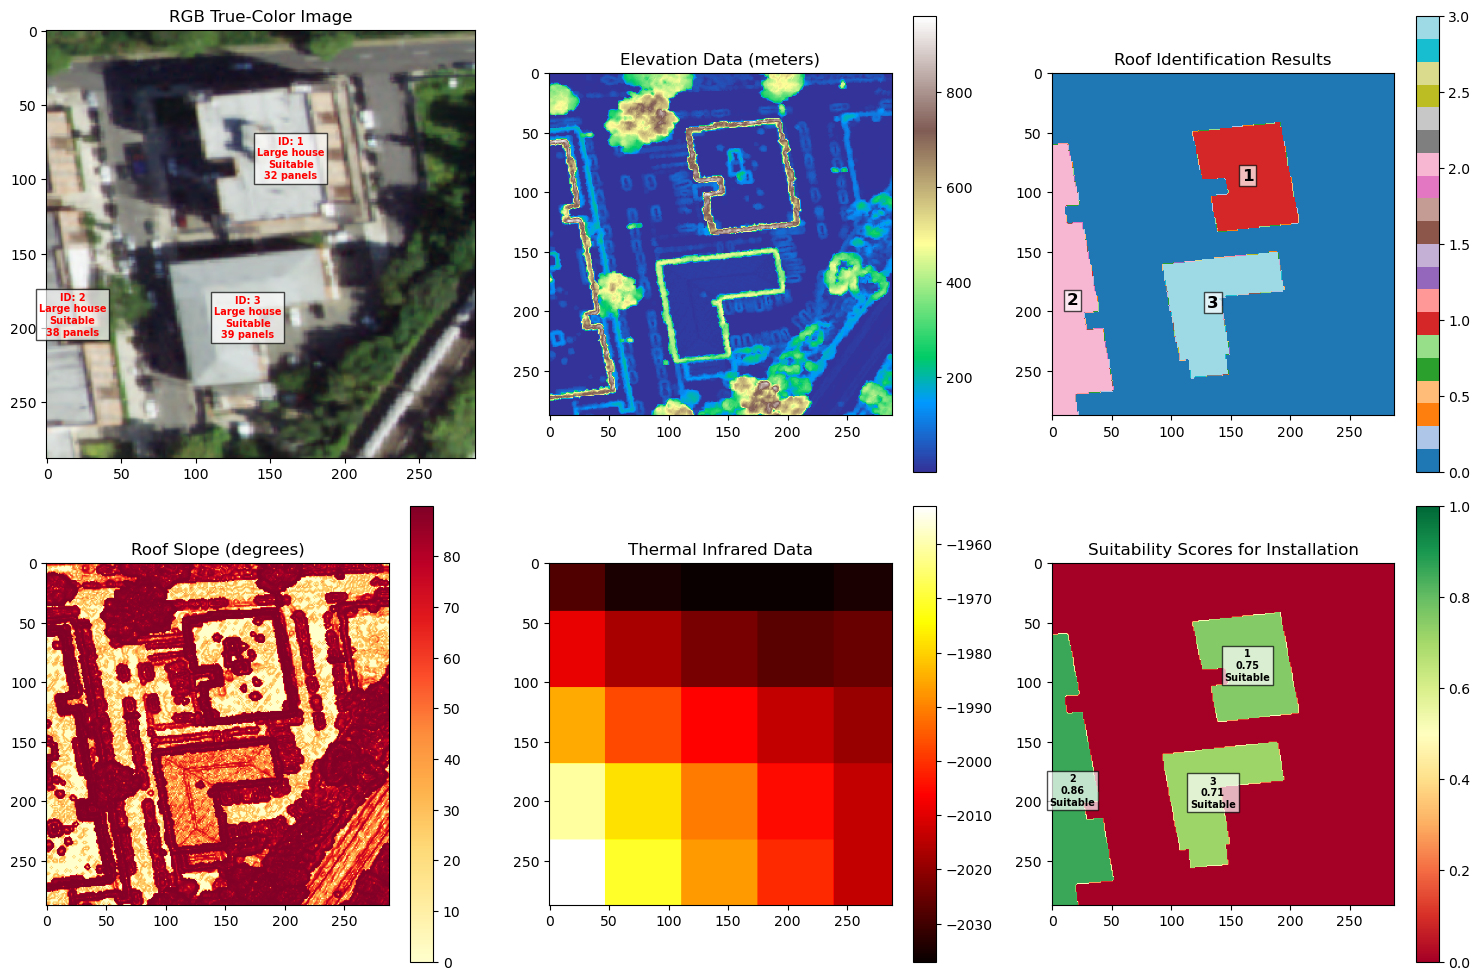


=== Solar Installation Potential Analysis Report ===
Number of identified roofs: 3
Number of suitable roofs: 3
Total number of solar panels that can be installed: 109
Estimated annual energy production: 46259.0 kWh
Estimated annual economic benefit: 23129.5 USD

Roof 1:
  Area: 1484.2 square meters (15976.5 square feet)
  House type: Large house
  Suitability score: 0.75
  Installation suitability assessment: Suitable
  Recommended number of panels: 32
  Actual number of panels that can be installed: 32
  Target monthly energy usage: 1877 kWh
  Estimated annual energy production: 13196.9 kWh
  Is flat roof: No

Roof 2:
  Area: 1728.8 square meters (18608.3 square feet)
  House type: Large house
  Suitability score: 0.86
  Installation suitability assessment: Suitable
  Recommended number of panels: 38
  Actual number of panels that can be installed: 38
  Target monthly energy usage: 1852 kWh
  Estimated annual energy production: 17849.2 kWh
  Is flat roof: No

Roof 3:
  Area: 1453.0 s

In [7]:
if __name__ == "__main__":
    # analyze a specific location
    results = analyze_solar_potential(xar, location_idx=100)